P(X=0) no reaction: 0.950
P(X=1) reaction:    0.050

Empirical proportion with reaction: 0.046


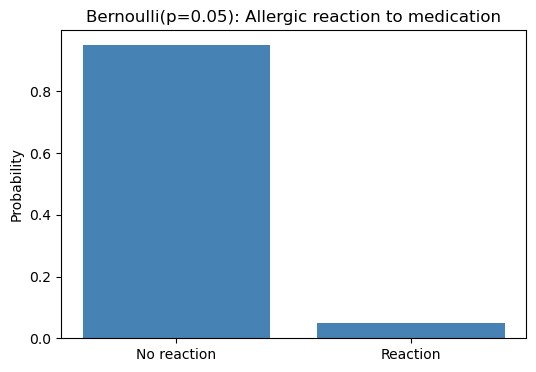

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Bernoulli: probability of allergic reaction, p = 0.05
p = 0.05
bernoulli_rv = stats.bernoulli(p)

# PMF at each outcome
print(f"P(X=0) no reaction: {bernoulli_rv.pmf(0):.3f}")
print(f"P(X=1) reaction:    {bernoulli_rv.pmf(1):.3f}")

# Simulate 1000 patients
samples = bernoulli_rv.rvs(size=1000, random_state=42)
print(f"\nEmpirical proportion with reaction: {samples.mean():.3f}")

plt.figure(figsize=(6,4))
plt.bar([0,1], [bernoulli_rv.pmf(0), bernoulli_rv.pmf(1)], color='steelblue')
plt.xticks([0,1], ['No reaction', 'Reaction'])
plt.ylabel('Probability')
plt.title(f'Bernoulli(p={p}): Allergic reaction to medication')
plt.show()

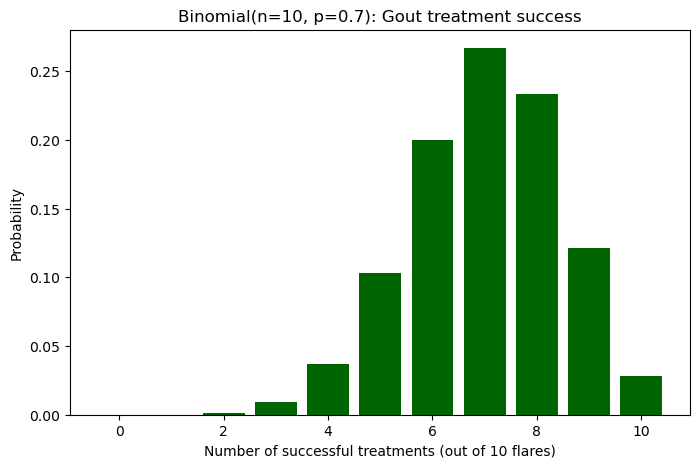

Expected successes: 7.00
P(exactly 7 successes): 0.267
P(at least 8 successes): 0.383


In [2]:
# Binomial: n = 10 gout flares, p = 0.7 probability treatment works on each
n = 10
p = 0.7
binomial_rv = stats.binom(n, p)

k_values = np.arange(0, n+1)
pmf_values = binomial_rv.pmf(k_values)

plt.figure(figsize=(8,5))
plt.bar(k_values, pmf_values, color='darkgreen')
plt.xlabel('Number of successful treatments (out of 10 flares)')
plt.ylabel('Probability')
plt.title(f'Binomial(n={n}, p={p}): Gout treatment success')
plt.show()

# Expected number of successes
print(f"Expected successes: {binomial_rv.mean():.2f}")  # = n*p
print(f"P(exactly 7 successes): {binomial_rv.pmf(7):.3f}")
print(f"P(at least 8 successes): {1 - binomial_rv.cdf(7):.3f}")  # cdf(7) = P(X<=7)

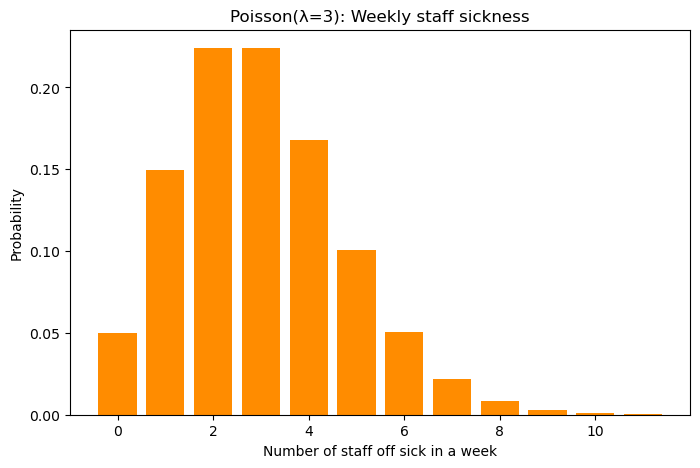

P(exactly 3 off sick): 0.224
P(more than 5 off sick): 0.084
Mean = Variance = λ: mean=3.0, var=3.0


In [3]:
# Poisson: average 3 staff off sick per week
lam = 3
poisson_rv = stats.poisson(lam)

k_values = np.arange(0, 12)
pmf_values = poisson_rv.pmf(k_values)

plt.figure(figsize=(8,5))
plt.bar(k_values, pmf_values, color='darkorange')
plt.xlabel('Number of staff off sick in a week')
plt.ylabel('Probability')
plt.title(f'Poisson(λ={lam}): Weekly staff sickness')
plt.show()

print(f"P(exactly 3 off sick): {poisson_rv.pmf(3):.3f}")
print(f"P(more than 5 off sick): {1 - poisson_rv.cdf(5):.3f}")
print(f"Mean = Variance = λ: mean={poisson_rv.mean()}, var={poisson_rv.var()}")

In [4]:
np.random.seed(42)
n_flares = 10
n_patients = 5000

# Scenario A: constant p (proper binomial assumption)
p_constant = 0.7
successes_constant = stats.binom.rvs(n_flares, p_constant, size=n_patients)

# Scenario B: p changes halfway (e.g. furosemide started after flare 5, raising urate -> lowering treatment success)
p_first_half = 0.7
p_second_half = 0.4  # treatment less effective after urate rises
successes_changing = np.array([
    stats.binom.rvs(5, p_first_half) + stats.binom.rvs(5, p_second_half)
    for _ in range(n_patients)
])

print(f"Scenario A (constant p) - mean successes: {successes_constant.mean():.2f}")
print(f"Scenario B (changing p) - mean successes: {successes_changing.mean():.2f}")
print(f"\nTheoretical binomial mean if we WRONGLY assumed constant p=0.7: {10*0.7}")
print(f"Actual mean given the p change: {5*0.7 + 5*0.4}")

Scenario A (constant p) - mean successes: 7.02
Scenario B (changing p) - mean successes: 5.48

Theoretical binomial mean if we WRONGLY assumed constant p=0.7: 7.0
Actual mean given the p change: 5.5
